In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras import layers, Model

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [2]:
(x_train, _), (x_test, _) = tf.keras.datasets.mnist.load_data()

print("Training data shape:", x_train.shape)
print("Testing data shape:", x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (60000, 28, 28)
Testing data shape: (10000, 28, 28)


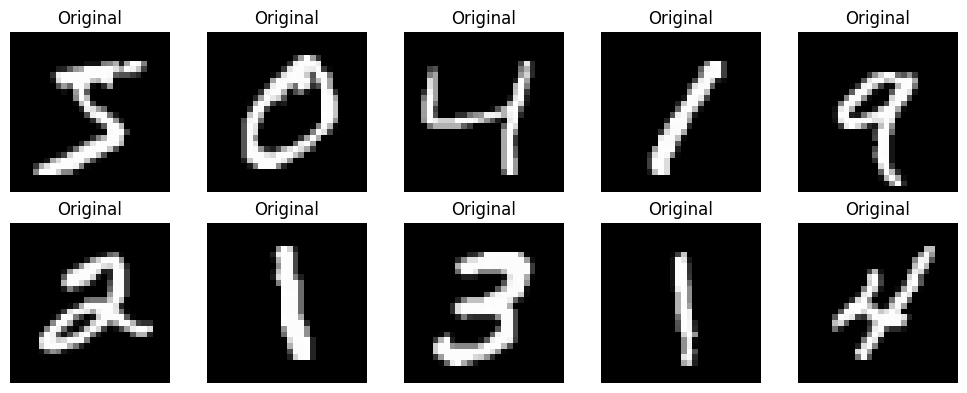

In [3]:
plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title("Original")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [4]:
# Convert pixel values from 0-255 to 0-1
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Add channel dimension
x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

print("New training shape:", x_train.shape)

New training shape: (60000, 28, 28, 1)


In [5]:
latent_dim = 2

In [6]:
# Input layer
encoder_inputs = layers.Input(shape=(28, 28, 1))

# Flatten image
x = layers.Flatten()(encoder_inputs)

# Hidden layers
x = layers.Dense(256, activation="relu")(x)
x = layers.Dense(128, activation="relu")(x)

# Mean and variance of latent distribution
z_mean = layers.Dense(latent_dim, name="z_mean")(x)
z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)

In [7]:
def sampling(args):

    z_mean, z_log_var = args

    batch = tf.shape(z_mean)[0]
    dim = tf.shape(z_mean)[1]

    # Generate random noise
    epsilon = tf.random.normal(shape=(batch, dim))

    # Reparameterization trick
    return z_mean + tf.exp(0.5 * z_log_var) * epsilon

In [8]:
z = layers.Lambda(sampling, name="z")(
    [z_mean, z_log_var]
)
encoder = Model(
    encoder_inputs,
    [z_mean, z_log_var, z],
    name="encoder"
)

encoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 784)       │          0 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    200,960 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │     32,896 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 2)         │        258 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 2)         │        258 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z (Lambda)          │ (None, 2)         │          0 │ z_mean[0][0],     │
│                     │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 234,372 (915.52 KB)

 Trainable params: 234,372 (915.52 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# Input to decoder
latent_inputs = layers.Input(shape=(latent_dim,))

# Hidden layers
x = layers.Dense(128, activation="relu")(latent_inputs)
x = layers.Dense(256, activation="relu")(x)

# Output layer
x = layers.Dense(
    28 * 28,
    activation="sigmoid"
)(x)

# Reshape to image
decoder_outputs = layers.Reshape(
    (28, 28, 1)
)(x)

# Create decoder model
decoder = Model(
    latent_inputs,
    decoder_outputs,
    name="decoder"
)

decoder.summary()

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 784)            │       201,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 28, 28, 1)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 234,896 (917.56 KB)

 Trainable params: 234,896 (917.56 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
class VAE(Model):

    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)

        self.encoder = encoder
        self.decoder = decoder

    def train_step(self, data):

        # Get input data
        if isinstance(data, tuple):
            data = data[0]

        # Start gradient calculation
        with tf.GradientTape() as tape:

            # Encode image
            z_mean, z_log_var, z = self.encoder(data)

            # Decode image
            reconstruction = self.decoder(z)

            # Reconstruction loss
            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(
                    tf.keras.losses.binary_crossentropy(
                        data,
                        reconstruction
                    ),
                    axis=(1, 2)
                )
            )

            # KL Divergence loss
            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(
                    1 + z_log_var
                    - tf.square(z_mean)
                    - tf.exp(z_log_var),
                    axis=1
                )
            )

            # Total loss
            total_loss = reconstruction_loss + kl_loss

        # Calculate gradients
        gradients = tape.gradient(
            total_loss,
            self.trainable_weights
        )

        # Update weights
        self.optimizer.apply_gradients(
            zip(gradients, self.trainable_weights)
        )

        return {
            "loss": total_loss,
            "reconstruction_loss": reconstruction_loss,
            "kl_loss": kl_loss
        }

In [11]:
vae = VAE(encoder, decoder)

vae.compile(
    optimizer=tf.keras.optimizers.Adam()
)
history = vae.fit(
    x_train,
    epochs=10,
    batch_size=128
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - kl_loss: 5.0705 - loss: 165.1190 - reconstruction_loss: 160.0486
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - kl_loss: 5.2314 - loss: 158.3393 - reconstruction_loss: 153.1079
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - kl_loss: 5.3427 - loss: 156.1460 - reconstruction_loss: 150.8032
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - kl_loss: 5.7283 - loss: 152.0510 - reconstruction_loss: 146.3227
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - kl_loss: 5.9188 - loss: 153.1732 - reconstruction_loss: 147.2545
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - kl_loss: 5.9200 - loss: 146.4184 - reconstruction_loss: 140.4984
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - kl_loss: 5.9083 - loss: 159.2673 - reconstruction_loss: 153.3591
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - kl_loss: 5.6829 - loss: 154.9125 - reconstruction_loss: 149.2296
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step


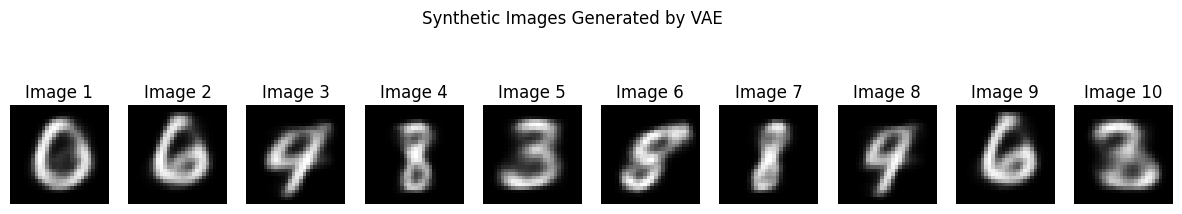

In [12]:
num_images = 10

# Generate random points in latent space
random_latent_vectors = np.random.normal(
    size=(num_images, latent_dim)
)

# Generate synthetic images
generated_images = decoder.predict(
    random_latent_vectors
)
plt.figure(figsize=(15, 3))

for i in range(num_images):

    plt.subplot(1, num_images, i + 1)

    plt.imshow(
        generated_images[i].reshape(28, 28),
        cmap="gray"
    )

    plt.title(f"Image {i+1}")

    plt.axis("off")

plt.suptitle("Synthetic Images Generated by VAE")

plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


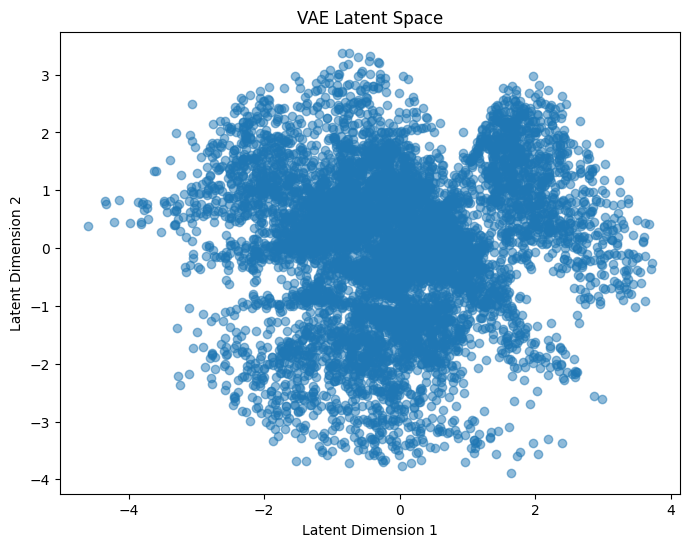

In [13]:
z_mean, _, _ = encoder.predict(x_test)

plt.figure(figsize=(8, 6))

plt.scatter(
    z_mean[:, 0],
    z_mean[:, 1],
    alpha=0.5
)

plt.xlabel("Latent Dimension 1")
plt.ylabel("Latent Dimension 2")

plt.title("VAE Latent Space")

plt.show()

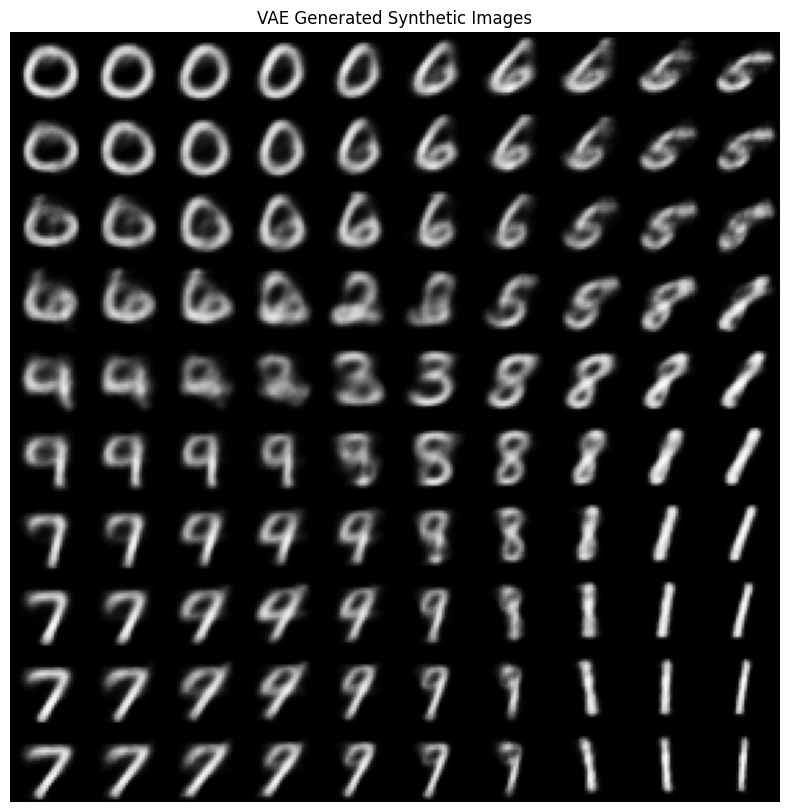

In [14]:
n = 10

figure = np.zeros((28 * n, 28 * n))

grid_x = np.linspace(-2, 2, n)
grid_y = np.linspace(-2, 2, n)

for i, yi in enumerate(grid_y):

    for j, xi in enumerate(grid_x):

        z_sample = np.array([[xi, yi]])

        generated_image = decoder.predict(
            z_sample,
            verbose=0
        )

        digit = generated_image[0].reshape(28, 28)

        figure[
            i * 28:(i + 1) * 28,
            j * 28:(j + 1) * 28
        ] = digit

plt.figure(figsize=(10, 10))

plt.imshow(
    figure,
    cmap="gray"
)

plt.title("VAE Generated Synthetic Images")

plt.axis("off")

plt.show()